<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Epidemiology</h1>
<h1>The Epidemiology of a Cognitive Virus</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

import epidemik
from epidemik import EpiModel, NetworkEpiModel

import watermark

%load_ext watermark
%matplotlib inline

To make it easier to test the compatibility of the running environment and to track changes in the used libraries, this notebook employs the `watermark` extension. For more information on the use of the extension, please check its [homepage](https://github.com/rasbt/watermark).

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.17.1

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 97bae774fa16046180bcb69e5605e1b930f629a6

epidemik  : 0.2.0
matplotlib: 3.11.1
networkx  : 3.6.1
numpy     : 2.5.3
pandas    : 3.0.5
watermark : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Set the colors for the compartments we will use
epidemik.utils.epi_colors.update({"U": colors[0], "C": colors[1], "D": colors[2]})
COLOR = epidemik.utils.epi_colors

## 1. The model

Three compartments, as fractions $u + c + d = 1$ of a population of size $N$:

| | Compartment | Meaning |
|---|---|---|
| $U$ | Uncoupled | doesn't use LLMs |
| $C$ | Coupled | casual/occasional user |
| $D$ | Dependent | persistently dependent user |

Four processes:

- **Social transmission** ($\beta$): non-users start using through contact with *any* user, casual or dependent — $U + C \xrightarrow{\beta} 2C$ and $U + D \xrightarrow{\beta} C + D$. The second channel is optional in the code below, and switching it on or off turns out to be the most consequential choice in the whole notebook.
- **Collective reinforcement** ($\alpha$): casual users become dependent through contact with the dependent — $C + D \xrightarrow{\alpha} 2D$. This is the paper's "collective reinforcement": dependence normalizes dependence.
- **Casual recovery** ($\gamma$): casual users drift away spontaneously — $C \xrightarrow{\gamma} U$
- **Slow de-escalation** ($\delta$): dependence decays only to casual use, never straight to non-use — $D \xrightarrow{\delta} C$

The mean-field equations, with both transmission channels active:

$$\dot{u} = -\beta\, u\,(c+d) + \gamma\, c$$
$$\dot{c} = \beta\, u\,(c+d) - \gamma\, c - \alpha\, c\, d + \delta\, d$$
$$\dot{d} = \alpha\, c\, d - \delta\, d$$

Drop the second channel and every $(c+d)$ above becomes a bare $c$.

Two structural choices matter: dependent users **still recruit** (the
$\beta u d$ term), and dependence is **only reachable through casual use and
only reinforced socially** (the $\alpha c d$ term — nobody becomes dependent
alone). The first is the `dependent_recruit` switch, off in §2 and §6 and on
in §4 and §5; it is what separates a gentle adoption ramp from a cliff.

## 2. Building the model in `epidemik`

`build_model` carries that switch. With it off — the default, and what we use
here — there is a single transmission channel, $U + C \xrightarrow{\beta} 2C$.
With it on, a second edge $U + D \xrightarrow{\beta} C + D$ is added through
`epidemik`'s string-expression rates (`rate='beta'`), so both channels always
share one parameter.

Hence the four transitions printed below, and the $R_0 = \beta/\gamma = 1.5$
that `epidemik` reports for the casual channel alone.

In [4]:
GAMMA, ALPHA, DELTA = 0.3, 1.0, 0.2   # baseline; c0 = delta/alpha = 0.2
N = 10_000

def build_model(beta, alpha=ALPHA, gamma=GAMMA, delta=DELTA, seed=None, dependent_recruit=False):
    m = EpiModel(compartments=["U", "C", "D"], seed=seed)
    m.add_interaction("U", "C", "C", beta=beta)          # casual users recruit
    if dependent_recruit:
        m.add_interaction("U", "C", "D", rate="beta")    # dependent users recruit too (off by default)
    m.add_interaction("C", "D", "D", alpha=alpha)        # collective reinforcement
    m.add_spontaneous("C", "U", gamma=gamma)             # casual recovery
    m.add_spontaneous("D", "C", delta=delta)             # slow de-escalation

    return m

model=build_model(0.45, dependent_recruit=False)
print(model)

# Epidemic Model with 3 compartments and 4 transitions:

Compartments: [U, C, D]

Parameters:
  beta: 0.45
  alpha: 1.0
  gamma: 0.3
  delta: 0.2

Transitions:
  - U + C = C beta
  - C + D = D alpha
  - C -> U gamma
  - D -> C delta

# R0=1.50



### A first run: does anyone become dependent?

Both runs below sit at $\beta = 0.45$ with recruitment off and start from 99.8%
non-users. They differ only in the seed: ten casual users and *no* dependents
(solid) against ten of each (dashed).

With $D = 0$ the dependent compartment is unreachable — $d = 0$ is invariant —
and the model collapses to plain SIS: non-use settles at
$u^* = \gamma/\beta = 2/3$ and casual use at $1 - \gamma/\beta = 1/3$. Ten
dependents are enough to change the destination: casual use still overshoots to
1/3, then reinforcement drains it back down to $c^* = \delta/\alpha = 0.2$ while
dependence saturates at $d^* = 1 - \gamma/\beta - \delta/\alpha \approx 0.13$.
The annotations mark those three levels.

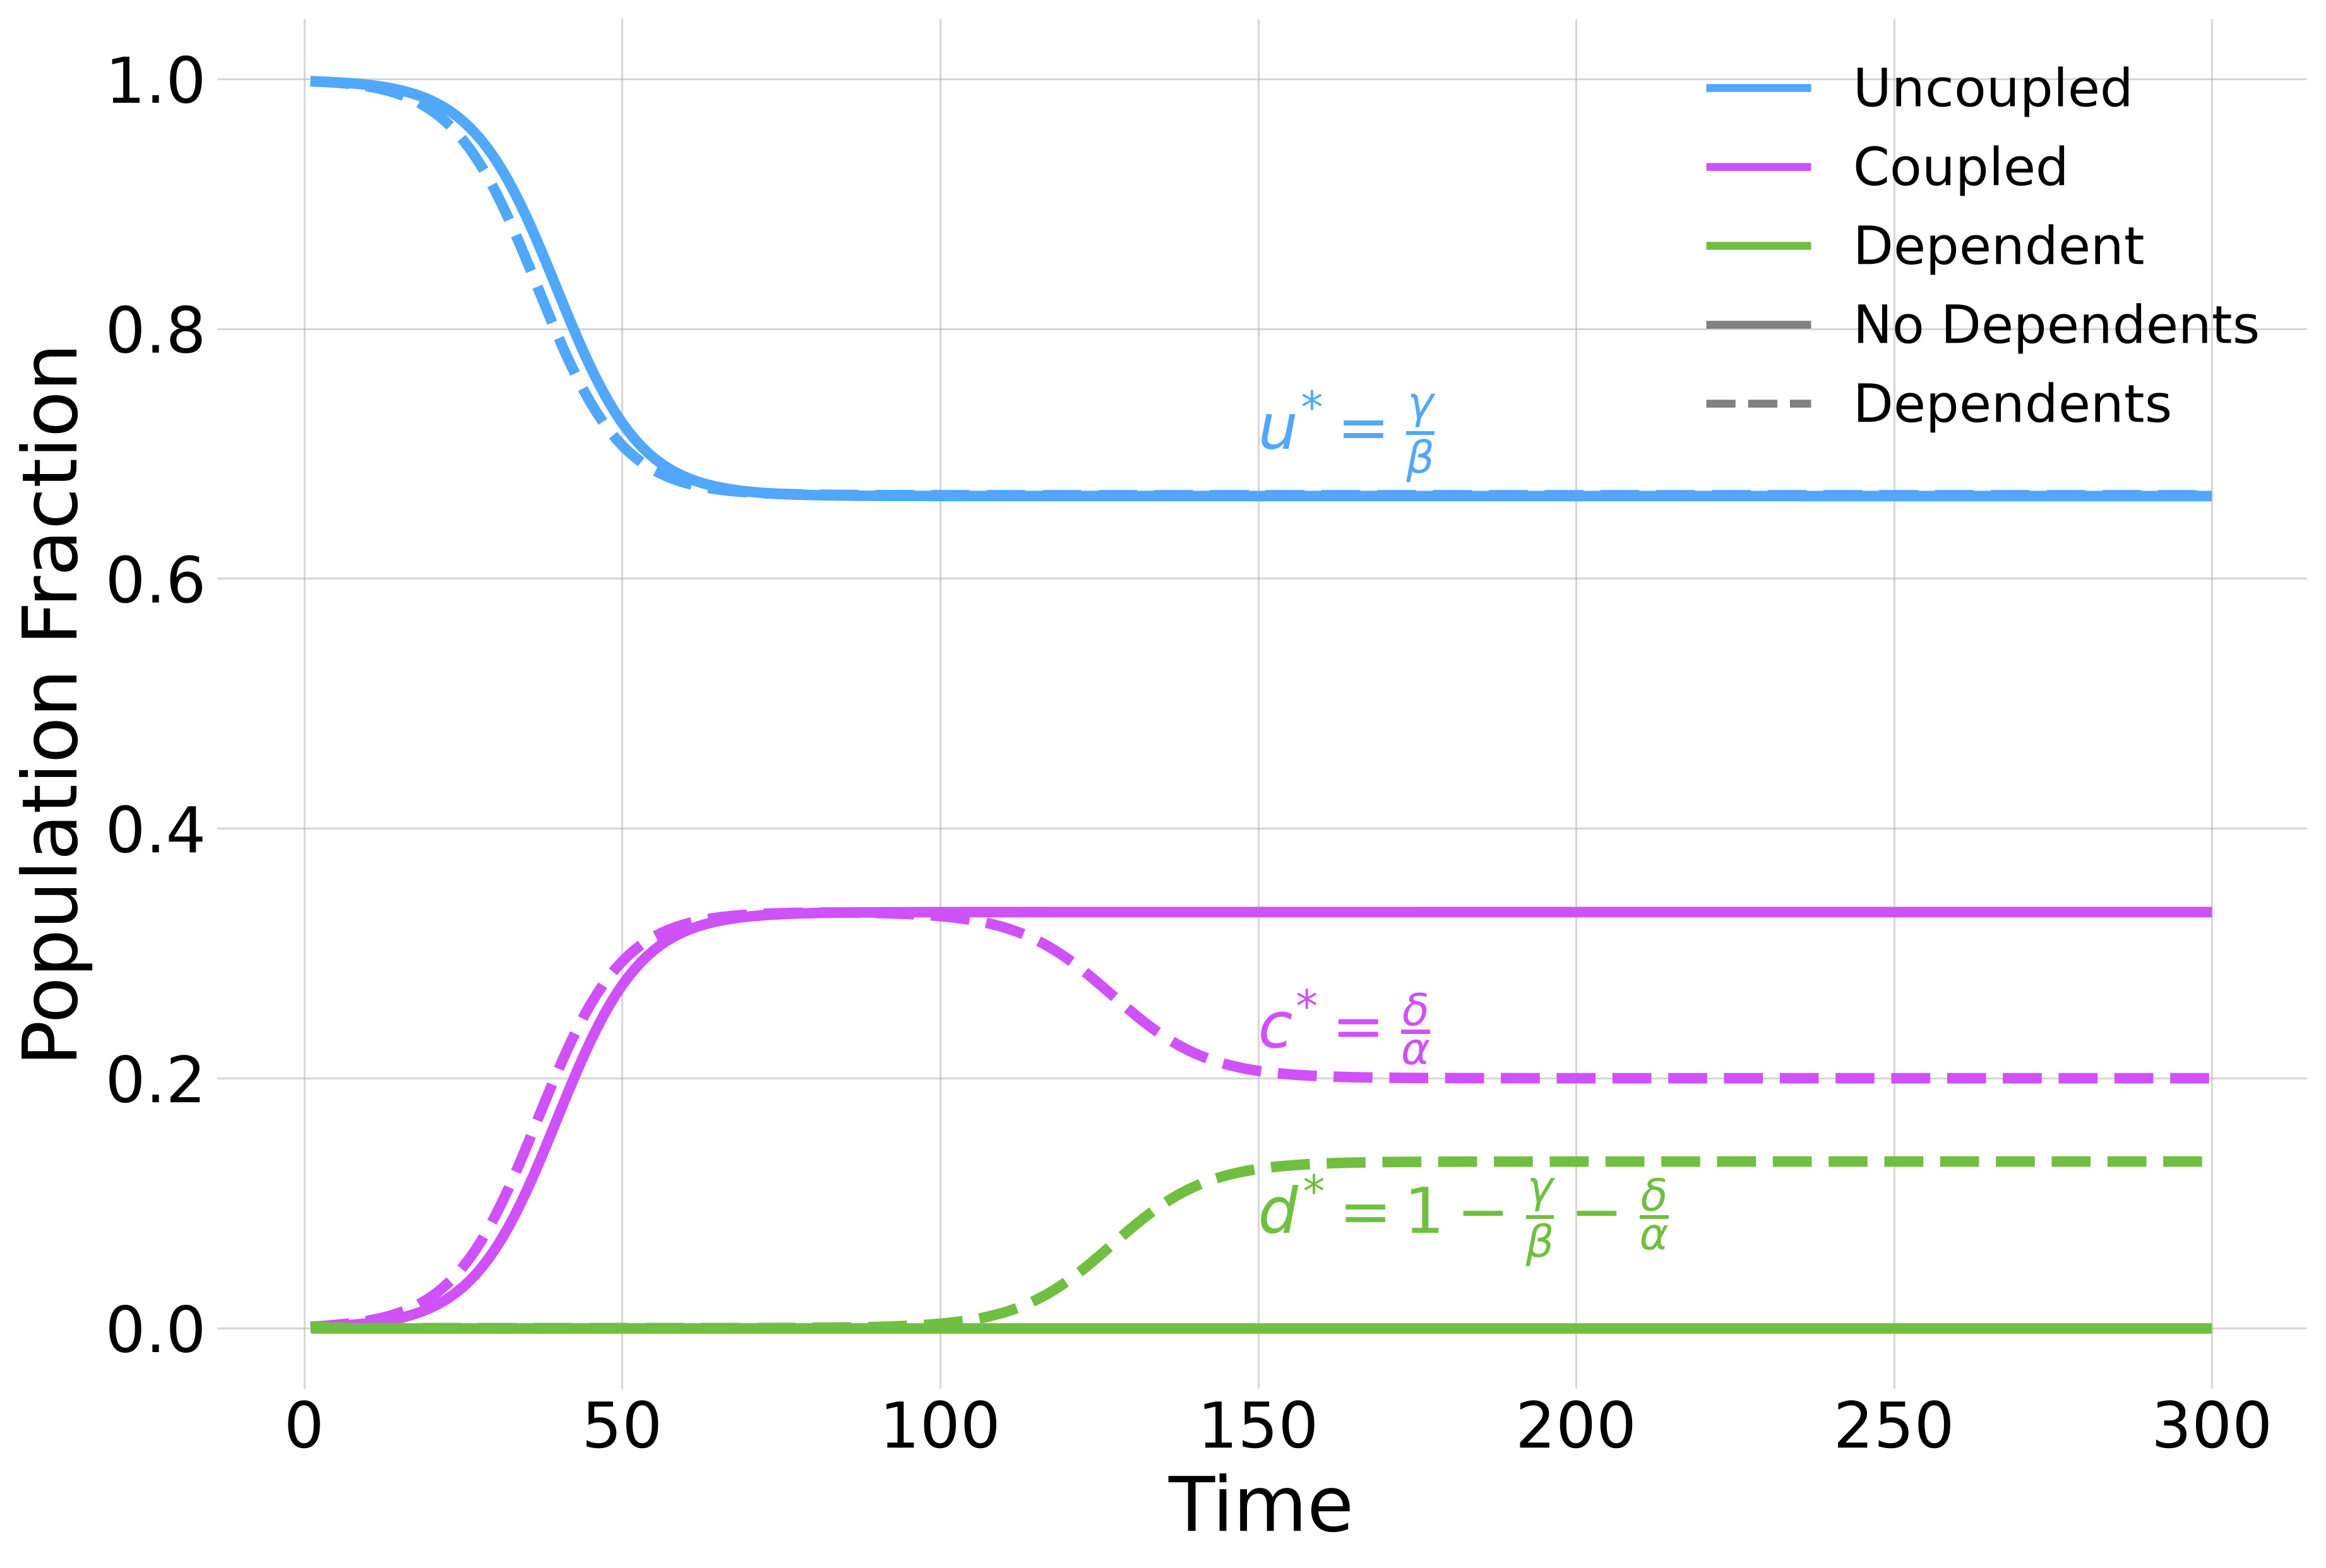

In [5]:
fig, ax = plt.subplots(1)

GAMMA = 0.3 
ALPHA = 1.0 
DELTA =  0.2   # baseline; c0 = delta/alpha = 0.2
N = 10_000

beta = 0.45

ax.text(150, GAMMA/beta+0.01, r"$u^{*}=\frac{\gamma}{\beta}$", color=colors[0], ha="left", va="bottom")
ax.text(150, DELTA/ALPHA+0.01, r"$c^{*}=\frac{\delta}{\alpha}$", color=colors[1], ha="left", va="bottom")
ax.text(150, 1-GAMMA/beta-DELTA/ALPHA-0.01, r"$d^{*}=1 - \frac{\gamma}{\beta} - \frac{\delta}{\alpha}$", color=colors[2], ha="left", va="top")
m0 = build_model(beta, dependent_recruit=False)
m0.integrate(300, U=N - 20, C=10, D=0, )    # no dependents seeded: d stays 0, SIS limit

m1 = build_model(beta, dependent_recruit=False)
m1.integrate(300, U=N - 20, C=10, D=10)     # 10 dependents: reinforcement engages

for comp, label in [("U", "Uncoupled"), ("C", "Coupled"), ("D", "Dependent")]:
    ax.plot(m0.values_.index, m0.values_[comp] / N, color=COLOR[comp], label=label)
    ax.plot(m1.values_.index, m1.values_[comp] / N, color=COLOR[comp], label=label, ls="--")

ax.set_xlabel("Time")
ax.set_ylabel("Population Fraction")

u_line = Line2D([0], [0], color=colors[0], lw=3)
c_line = Line2D([0], [0], color=colors[1], lw=3)
d_line = Line2D([0], [0], color=colors[2], lw=3)
gray_line = Line2D([0], [0], color='gray', lw=3)
dashed_line = Line2D([0], [0], color='gray', lw=3, ls="--")

handles = [u_line, c_line, d_line, gray_line, dashed_line]
labels = ['Uncoupled', 'Coupled', 'Dependent', 'No Dependents', 'Dependents']
ax.legend(handles, labels, loc="upper right", fontsize=20)

plt.tight_layout()

## 3. Fixed points and three thresholds

**The casual-use thermostat.** The dependence equation
$\dot{d} = d\,(\alpha c - \delta)$ pins the interior equilibrium at

$$c^* = \frac{\delta}{\alpha} \equiv c_0$$

The share of *casual* users is set entirely by the dependence dynamics — not
by adoption. Push recruitment harder and the extra users don't accumulate as
casual users; they convert into dependents. That is the 20% plateau in the
figure above, and it holds whether or not dependents recruit. Measured
"moderate use" staying flat while heavy use grows is exactly what this model
predicts — a point worth making in the essay, because it's the kind of
aggregate statistic that gets misread as "usage has plateaued."

**One channel or two.** With recruitment off, that is the whole story: the
interior equilibrium is unique, $u^* = \gamma/\beta$ and
$d^* = 1 - \gamma/\beta - c_0$, and dependence appears continuously once
$\beta$ clears $\gamma/(1 - c_0)$.

**The quadratic that creates the cliff.** Switch the second channel on and the
$u$-equation becomes $\beta(1 - x)x = \gamma c_0$ with $x = c + d$, so

$$x_\pm = \frac{1 \pm \sqrt{1 - 4\gamma c_0/\beta}}{2}$$

Two branches — a stable high-dependence state and an unstable separatrix —
born together in a saddle-node bifurcation. Three critical values of $\beta$
organize everything (baseline values for $\gamma=0.3$, $c_0=0.2$ in parentheses):

| Threshold | Value | Meaning |
|---|---|---|
| $\beta_{sn} = 4\gamma c_0$ | (0.24) | the locked-in state comes into existence |
| $\beta_{SIS} = \gamma$ | (0.30) | casual use alone becomes self-sustaining |
| $\beta_{inv} = \gamma/(1 - c_0)$ | (0.375) | dependence invades from small seeds — the takeoff |

Between $\beta_{sn}$ and $\beta_{inv}$ the system is **bistable**: where you
end up depends on where you start. And note the ordering: for
$\beta \in (\beta_{sn}, \beta_{SIS})$ the locked-in state survives *below*
the classic epidemic threshold — casual use alone couldn't even sustain
itself there, but entrenched dependence can.

In [6]:
c0 = DELTA / ALPHA
beta_sn, beta_sis, beta_inv = 4 * GAMMA * c0, GAMMA, GAMMA / (1 - c0)
print(f"c0 = {c0:.3f} | beta_sn = {beta_sn:.3f} | beta_SIS = {beta_sis:.3f} | beta_inv = {beta_inv:.3f}")

c0 = 0.200 | beta_sn = 0.240 | beta_SIS = 0.300 | beta_inv = 0.375


## 4. The key figure: a first-order transition, with hysteresis

Numerical continuation with `epidemik`, with dependent recruitment forced on
inside the `equilibrium` helper: sweep $\beta$ upward carrying each equilibrium
forward as the next initial condition (with a tiny re-seed of one individual in
$C$ and $D$, since $d = 0$ is invariant), then sweep back down starting from a
locked-in $(u, c, d) = (0.1, 0.2, 0.7)$. Every point is integrated for 6000
steps.

In [7]:
def equilibrium(beta, U0, C0, D0, T=6000, **kw):
    m = build_model(beta, dependent_recruit=True, **kw)   # recruitment on for the whole sweep
    m.integrate(T, U=U0, C=C0, D=D0)
    eq = m.values_.iloc[-1]
    return eq

betas = np.linspace(0.16, 0.50, 35)

state = (N - 2, 1.0, 1.0)      # forward sweep: carry each equilibrium into the next beta
forward = []
for b in betas:
    eq = equilibrium(b, *state)
    forward.append(eq["D"] / N)
    state = (max(eq["U"], 0.0), max(eq["C"], 1.0), max(eq["D"], 1.0))

state = (N * 0.1, N * 0.2, N * 0.7)      # backward sweep: start from the locked-in state
backward = []
for b in betas[::-1]:
    eq = equilibrium(b, *state)
    backward.append(eq["D"] / N)
    state = (max(eq["U"], 0.0), max(eq["C"], 1.0), max(eq["D"], 1.0))
backward = backward[::-1]

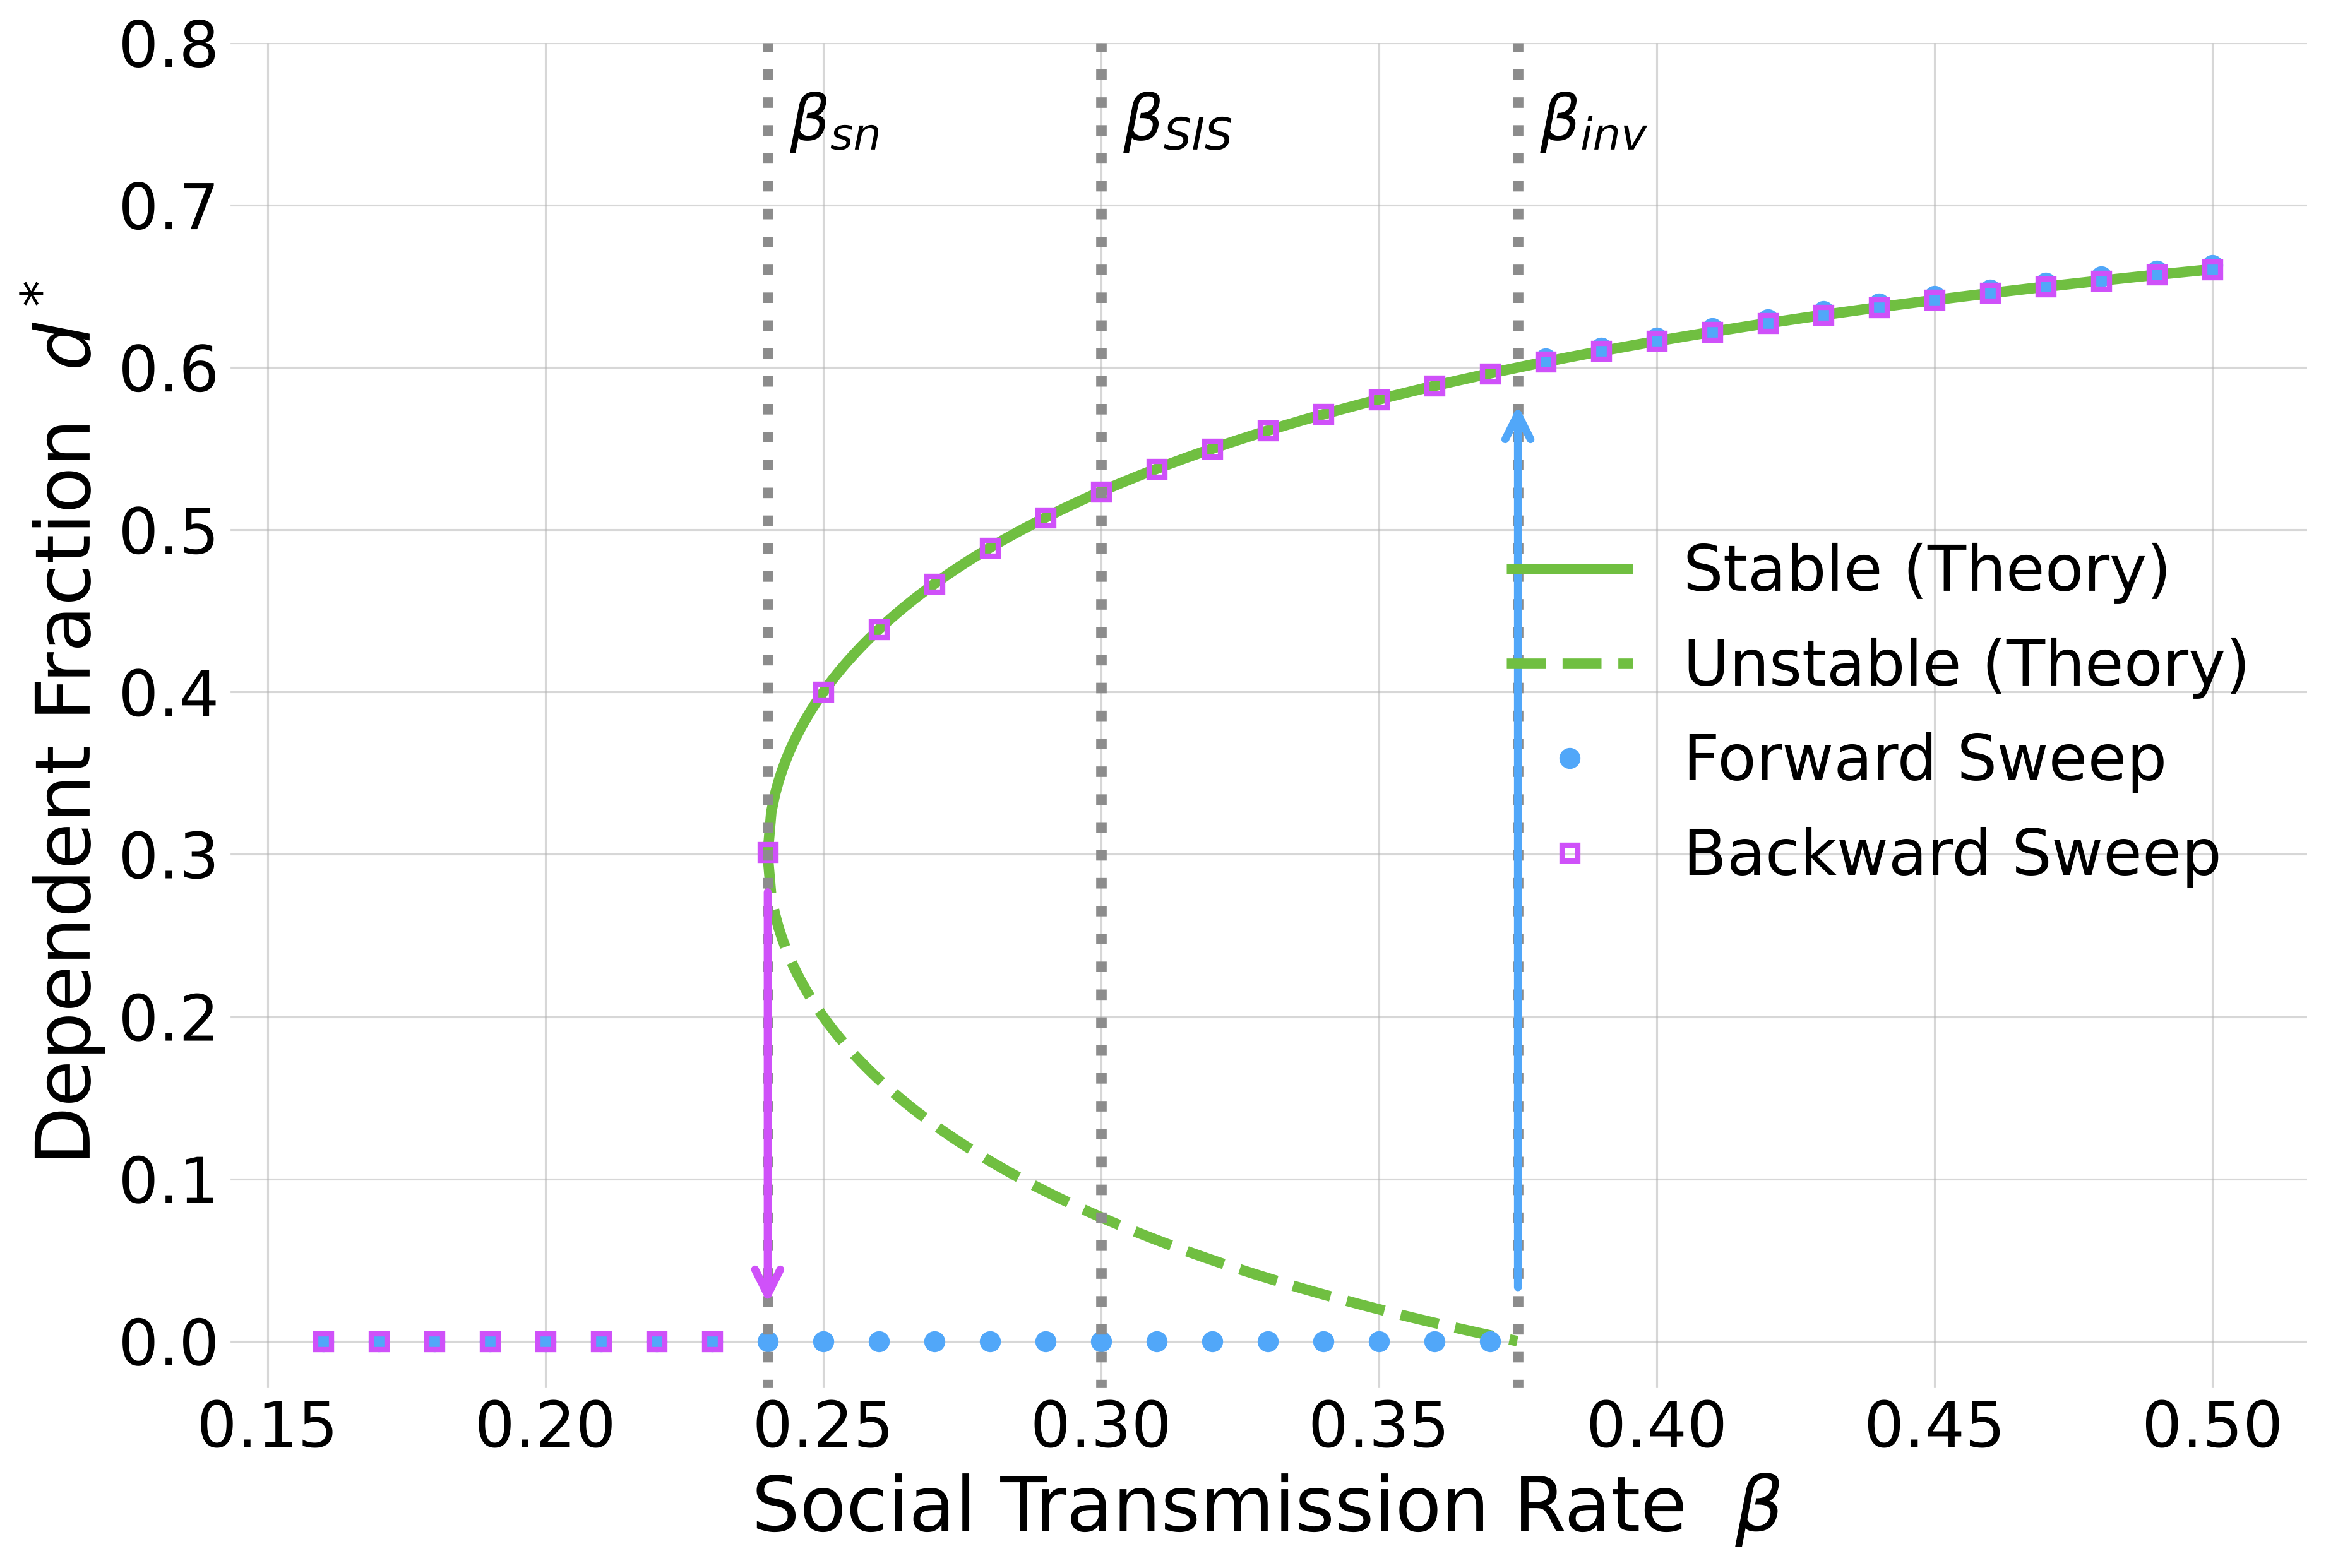

In [8]:
# analytic branches
bb = np.linspace(beta_sn, 0.50, 400)
disc = np.sqrt(np.clip(1 - 4 * GAMMA * c0 / bb, 0, None))
d_hi, d_lo = (1 + disc) / 2 - c0, (1 - disc) / 2 - c0

fig, ax = plt.subplots()
ax.plot(bb, d_hi, color=colors[2], label="Stable (Theory)")
ax.plot(bb[d_lo > 0], d_lo[d_lo > 0], color=colors[2], ls="--",
        label="Unstable (Theory)")
ax.plot(betas, forward, "o", color=colors[0], ms=7, label="Forward Sweep")
ax.plot(betas, backward, "s", color=colors[1], ms=6, mfc="none", mew=2,
        label="Backward Sweep")

for x, name in [(beta_sn, r"$\beta_{sn}$"), (beta_sis, r"$\beta_{SIS}$"),
                (beta_inv, r"$\beta_{inv}$")]:
    ax.axvline(x, color="0.55", ls=":")
    ax.annotate(name, (x+0.004, 0.74), ha="left", fontsize=24)

ax.annotate("", xy=(beta_inv , 0.58), xytext=(beta_inv, 0.03),
            arrowprops=dict(arrowstyle="->", color=colors[0], linewidth=3))
ax.annotate("", xy=(beta_sn , 0.02), xytext=(beta_sn , 0.28),
            arrowprops=dict(arrowstyle="->", color=colors[1], linewidth=3))

ax.set_xlabel(r"Social Transmission Rate  $\beta$")
ax.set_ylabel(r"Dependent Fraction  $d^*$")
ax.set_ylim(-0.03, 0.80)
ax.legend(loc="center right")
plt.tight_layout()

This is the figure the essay hangs on. Reading it left to right: nothing,
nothing, nothing — then at $\beta_{inv}$ the dependent fraction jumps
*discontinuously* from zero to ~60%. No warning in the aggregate statistics,
no gradually rising curve to alarm anyone. And coming back down (the open
squares): reducing transmission does **not** retrace the path. The locked-in
state persists all the way down to $\beta_{sn}$ — still holding ~30% of the
population dependent at the moment it collapses — including the region below
$\beta_{SIS}$ where casual use alone would die out. *The conditions that
created mass dependence are not the conditions required to maintain it.*

One term accounts for all of it. At $\beta = 0.45$ the single-channel model of
§2 settled at 13% dependent; with dependents recruiting, the same $\beta$ sits
at ~64% on the upper branch. Dependent users remaining socially transmissive is
what turns the ramp into a cliff — heavy users don't merely consume the
technology, they *are* its most visible advertisement, in feeds, in workflows,
in what colleagues see working.

## 5. Beyond mean-field: networks move the tipping point

Mean-field assumes everyone interacts with everyone. Real influence flows over
heterogeneous contact networks, and for epidemics on networks the threshold
scales as $\langle k \rangle / \langle k^2 \rangle$ — degree fluctuations eat
the threshold. Does the same happen to the *dependence* transition?

We rebuild the model with `NetworkEpiModel` on two graphs of $N = 1000$ nodes
with the same average degree $\langle k \rangle \approx 6$: an Erdős–Rényi
graph (narrow degrees) and a Barabási–Albert graph (broad degrees), sweeping
the *per-contact* transmission probability $\lambda$ over four seeds per point,
400 steps each, averaging the last 50. Two things differ from the mean-field
runs: both transmission channels are always present here (the second declared
as its own parameter, `beta2`, set to the same $\lambda$), and reinforcement
and de-escalation are slower, $\alpha = 0.15$ and $\delta = 0.10$.

*(This cell is the slow one — a few minutes.)*

In [9]:
N_NET = 1000
G_BA = nx.barabasi_albert_graph(N_NET, 3, seed=42)
kavg = 2 * G_BA.number_of_edges() / N_NET
G_ER = nx.gnp_random_graph(N_NET, kavg / (N_NET - 1), seed=42)

NET_GAMMA, NET_ALPHA, NET_DELTA = 0.3, 0.15, 0.10   # slower reinforcement/de-escalation than mean field

def run_network(G, lam, seed, T=400):
    m = NetworkEpiModel(G)
    m.add_interaction("U", "C", "C", beta=lam)
    m.add_interaction("U", "C", "D", beta2=lam)   # dependents recruit too, same per-contact rate
    m.add_interaction("C", "D", "D", alpha=NET_ALPHA)
    m.add_spontaneous("C", "U", None, gamma=NET_GAMMA)
    m.add_spontaneous("D", "C", None, delta=NET_DELTA)
    rng = np.random.default_rng(seed)
    seeds = {i: "U" for i in G.nodes}          # seed every node explicitly
    for i in rng.choice(N_NET, 30, replace=False):
        seeds[i] = "C"
    for i in rng.choice(N_NET, 10, replace=False):
        seeds[i] = "D"
    m.simulate(T, seeds=seeds)
    d = m.values_["D"].iloc[-50:].mean() / N_NET if "D" in m.values_ else 0.0   # late-time average
    return d, m

lams = np.array([0.02, 0.025, 0.03, 0.035, 0.04, 0.05, 0.06, 0.08])
SEEDS = (1, 2, 3, 4)
runs = {}
for name, G in [("Erdős–Rényi", G_ER), ("Barabási–Albert", G_BA)]:
    runs[name] = np.array([[run_network(G, lam, s)[0] for s in SEEDS]
                           for lam in lams])
    print(name, np.round(runs[name].mean(axis=1), 3))

Erdős–Rényi [0.    0.    0.    0.    0.565 0.614 0.646 0.677]
Barabási–Albert [0.226 0.298 0.334 0.485 0.509 0.566 0.602 0.64 ]


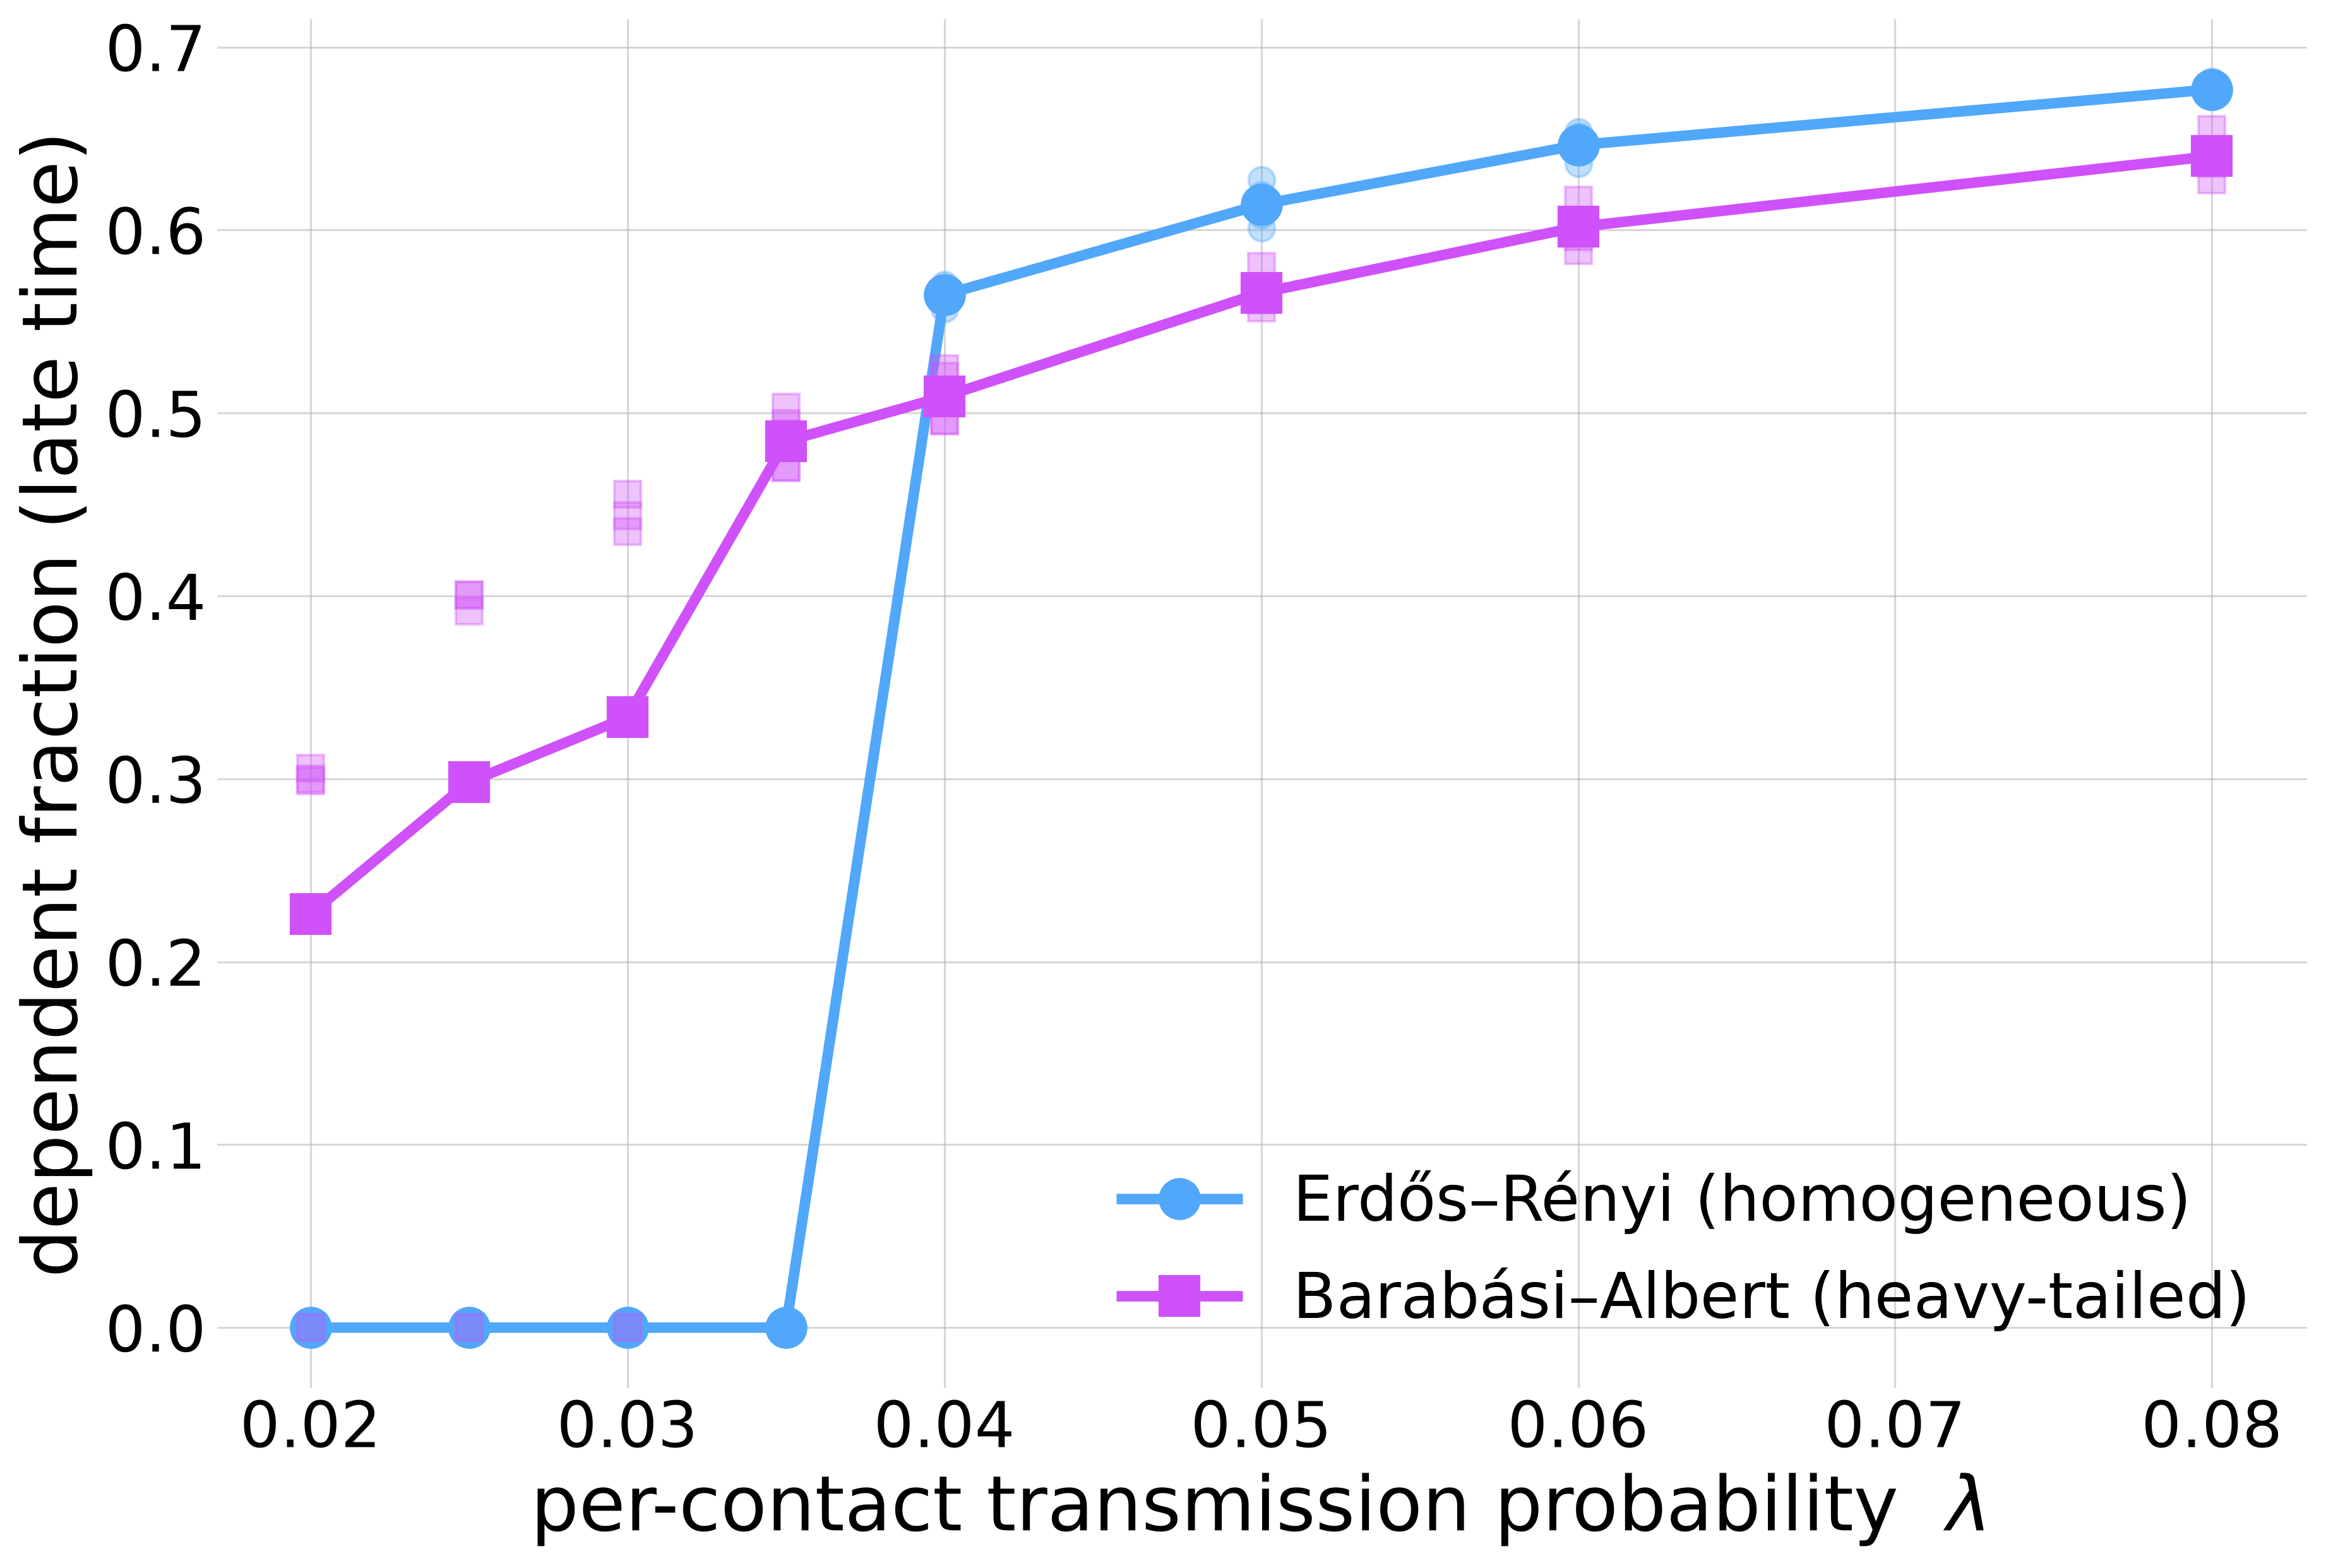

In [10]:
fig, ax = plt.subplots()
for name, color, marker, kind in [("Erdős–Rényi", colors[0], "o", "homogeneous"),
                                  ("Barabási–Albert", colors[1], "s", "heavy-tailed")]:
    r = runs[name]
    for k, lam in enumerate(lams):
        ax.plot([lam] * r.shape[1], r[k], marker, color=color, ms=10, alpha=0.35)
    ax.plot(lams, r.mean(axis=1), marker + "-", color=color, ms=15,
            label=f"{name} ({kind})")
ax.set_xlabel(r"per-contact transmission probability  $\lambda$")
ax.set_ylabel("dependent fraction (late time)")
ax.legend(loc="lower right")
plt.tight_layout()

Same average degree, same rates — and two completely different transitions.
The homogeneous graph reproduces the mean-field cliff: exactly zero dependence
up to $\lambda = 0.035$, then a jump to 57% at $\lambda = 0.04$. The
heavy-tailed graph has no cliff at all. It already carries 23% dependents at
$\lambda = 0.02$, where the Erdős–Rényi graph shows *nothing whatsoever*, and
climbs smoothly from there. Hubs act as both super-recruiters and reinforcement
chambers: once a hub's neighborhood tips it stays tipped and radiates, so
dependence survives at transmission rates that sustain nothing at all on a
homogeneous graph. The faint per-run dots show how noisy that regime is —
individual Barabási–Albert runs at low $\lambda$ land anywhere between ~20% and
~45%, while every Erdős–Rényi run below its threshold sits exactly at zero.

Past $\lambda \approx 0.04$ the two curves cross and the homogeneous graph ends
up slightly higher: once transmission is easy everywhere, hubs stop being an
advantage and the scale-free graph's many low-degree leaves become a liability.
So heterogeneity doesn't simply make things worse — it moves the onset earlier
and flattens the cliff into a ramp. Either way, mean-field is the *best case*,
and quoting a single threshold number from it understates when trouble starts.

And *who* gets locked in is not uniform either:

In [11]:
_, m_ba = run_network(G_BA, 0.05, seed=3)   # one run comfortably above the network threshold
occupancy_ba = (m_ba.population_.iloc[-100:] == "D").mean(axis=0)   # share of the last 100 steps spent dependent
degrees_ba = pd.Series(dict(G_BA.degree()))
df_ba = pd.DataFrame({"k": degrees_ba, "occ": occupancy_ba})


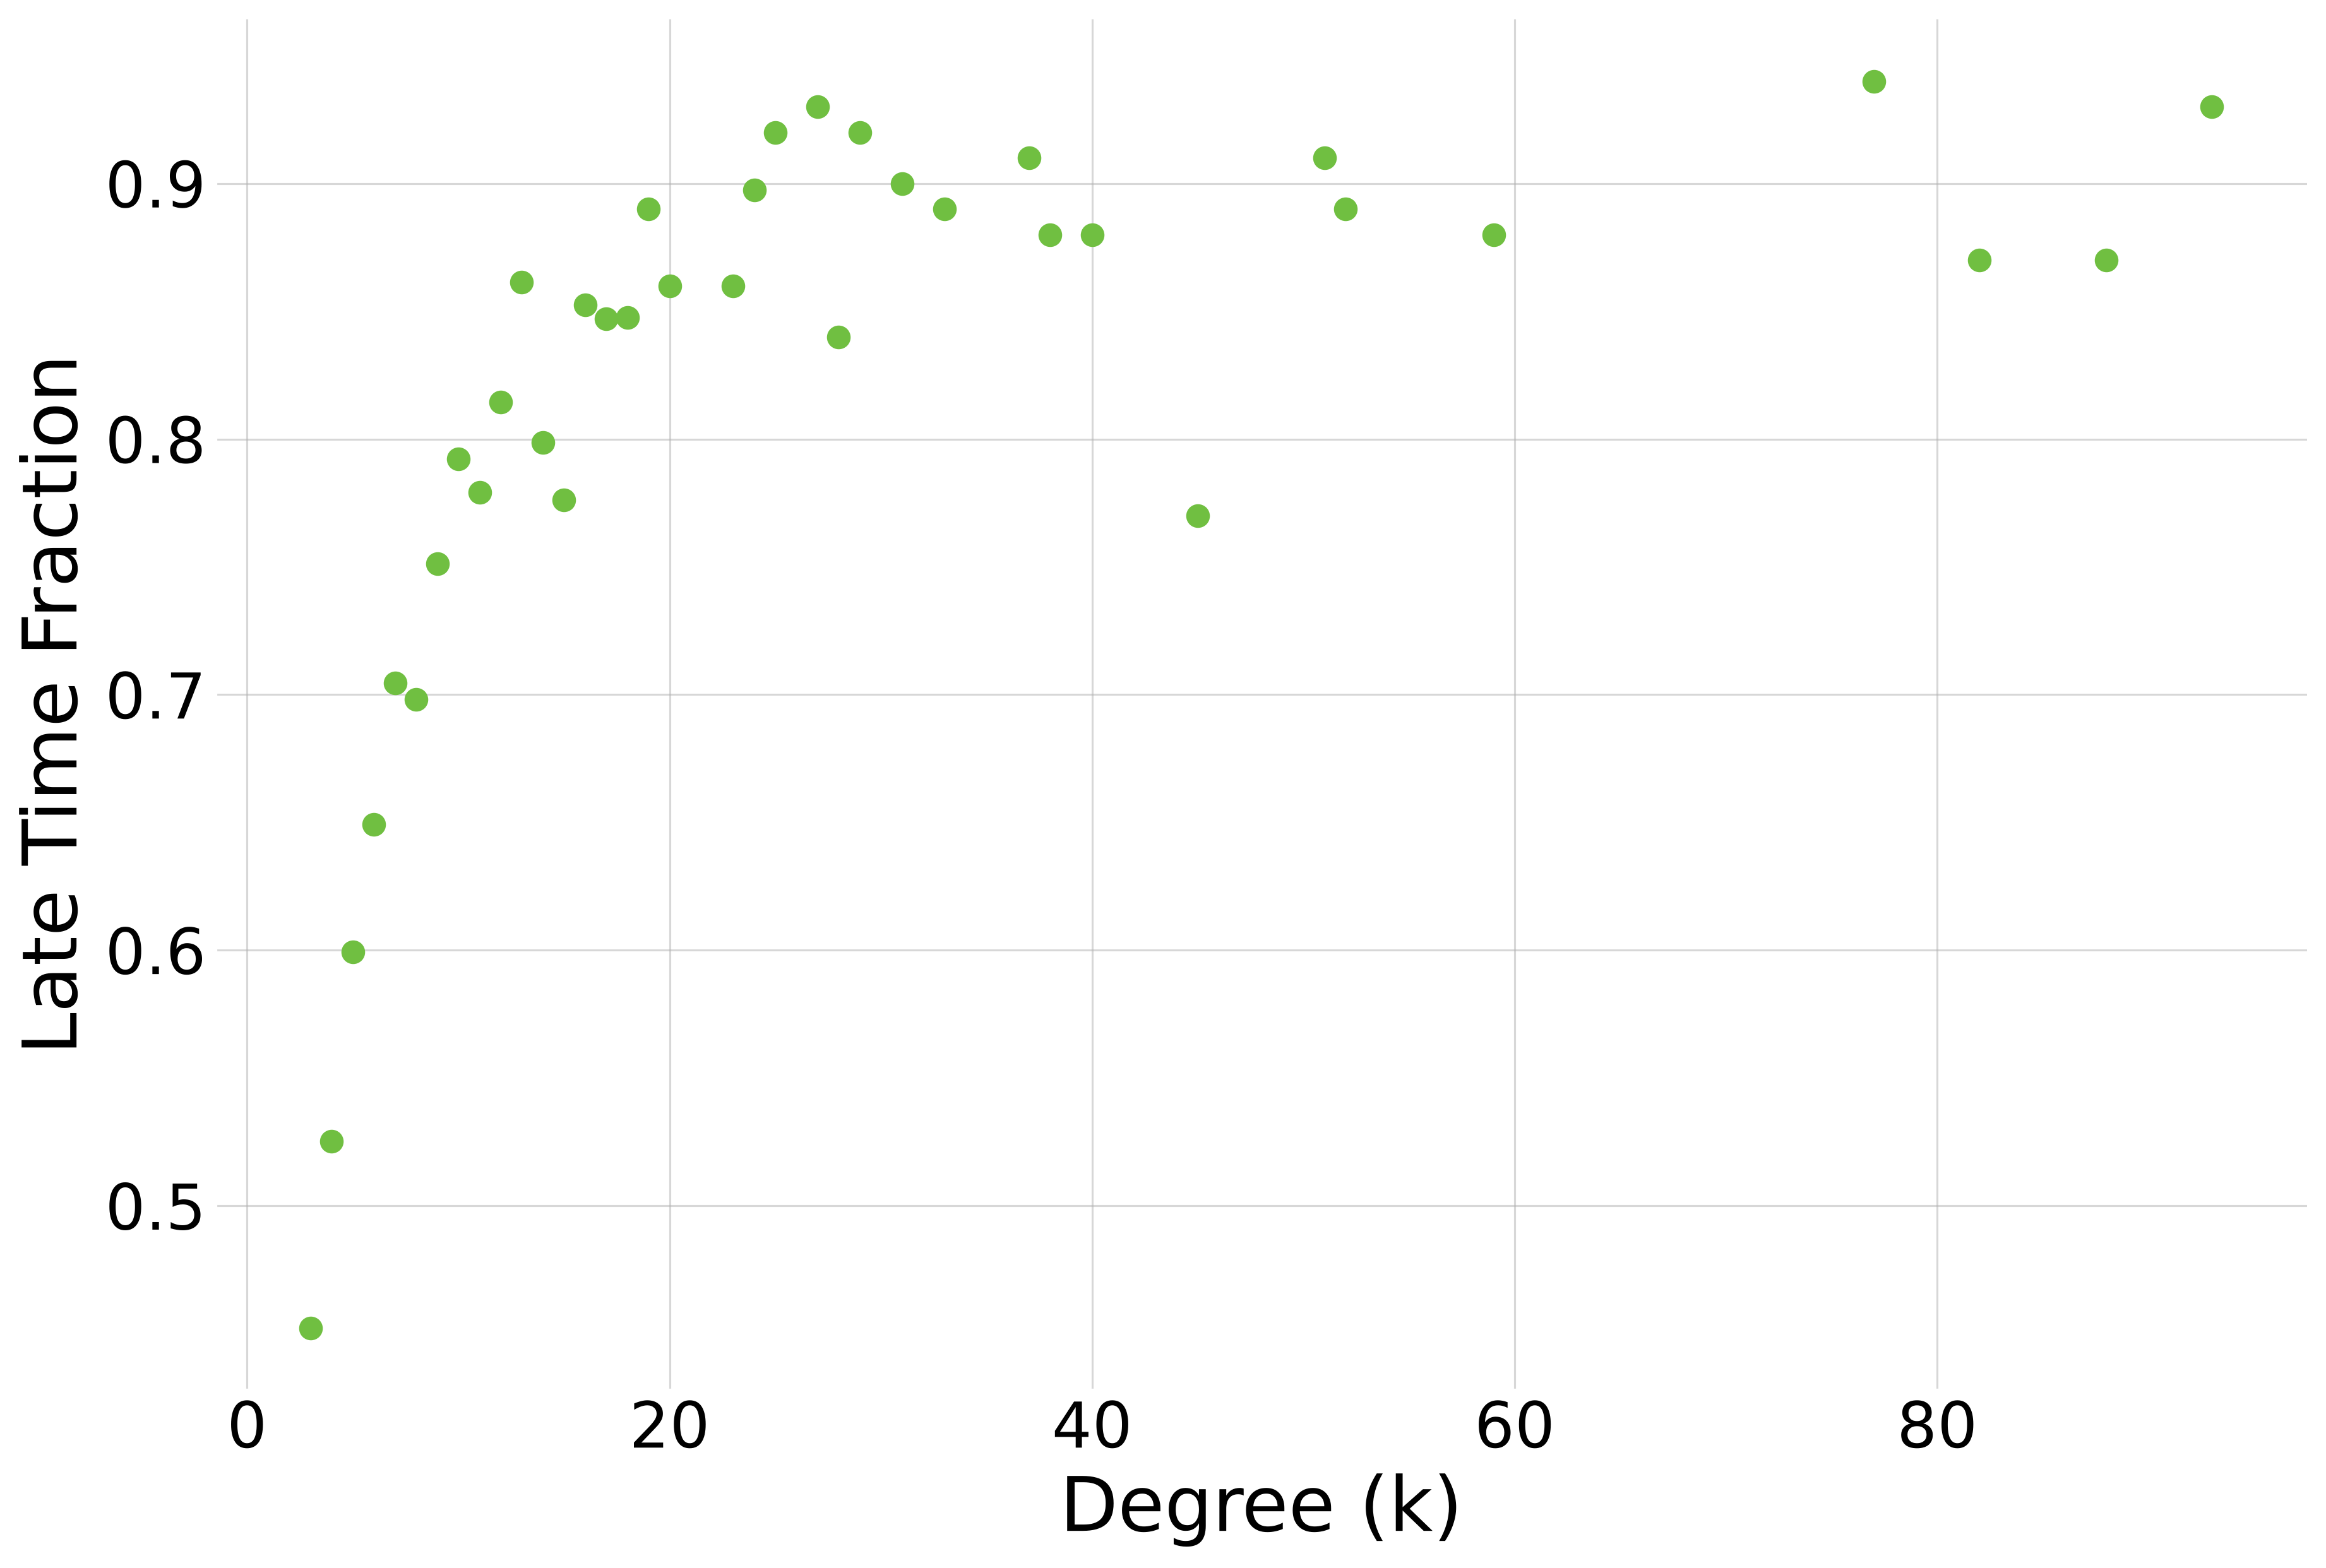

In [12]:
fig, ax = plt.subplots()
dep = df_ba[['k', 'occ']].groupby('k').mean()
ax.scatter(dep.index, dep.occ, color=colors[2], lw=3)
ax.set_xlabel("Degree (k)")
ax.set_ylabel("Late Time Fraction")
plt.tight_layout()


Time spent dependent climbs steeply with degree and then saturates: degree-3
nodes are dependent about 45% of the late-time window, degree-10 nodes about
80%, and everything above $k \approx 20$ sits mostly between 85% and 95%,
hub or not.
The best-connected people are effectively never out of the dependent state. If
the model has any purchase on reality, the visible early
adopters-turned-power-users aren't an anecdote; they're a structural
prediction.

## 6. Interventions: reversibility beats transmission control

The paper's "cognitive immunization" proposals reduce to two levers: lower
$\beta$ (friction on social transmission) or raise $\delta$ (make dependence
easier to step back from). In the model *with* recruitment, hysteresis makes
these levers wildly asymmetric once a population is locked in: the locked-in
state ceases to exist only when
$\beta < \beta_{sn}(\delta) = 4\gamma\delta/\alpha$, equivalently when
$\delta > \alpha\beta / 4\gamma$ — the escape boundary is *linear* in $\delta$,
and it is the line drawn on the map below.

Every run starts from the locked-in state $(u, c, d) = (0.1, 0.2, 0.7)$, on a
21×21 grid integrated for 3000 steps.

> **Code note:** the sweep calls `build_model` without `dependent_recruit=True`,
> so it maps the single-channel model instead. That model's escape boundary is
> $\delta = \alpha(1 - \gamma/\beta)$ — the edge of the green wedge — and it
> supports no dependence at all below $\beta = \gamma = 0.3$, which is why the
> drawn $\delta = \alpha\beta/4\gamma$ line and the two annotations sit in
> empty space. Turn the switch on to make the map and the line describe the
> same model.

In [13]:
n_grid = 21
betas_g = np.linspace(0.12, 0.50, n_grid)
deltas_g = np.linspace(0.05, 0.45, n_grid)
Z = np.zeros((n_grid, n_grid))
for i, dl in enumerate(deltas_g):
    for j, b in enumerate(betas_g):
        m = build_model(b, delta=dl)   # single channel: recruitment off (see the code note above)
        m.integrate(3000, U=N * 0.10, C=N * 0.20, D=N * 0.70)
        Z[i, j] = max(m.values_["D"].iloc[-1] / N, 0.0)

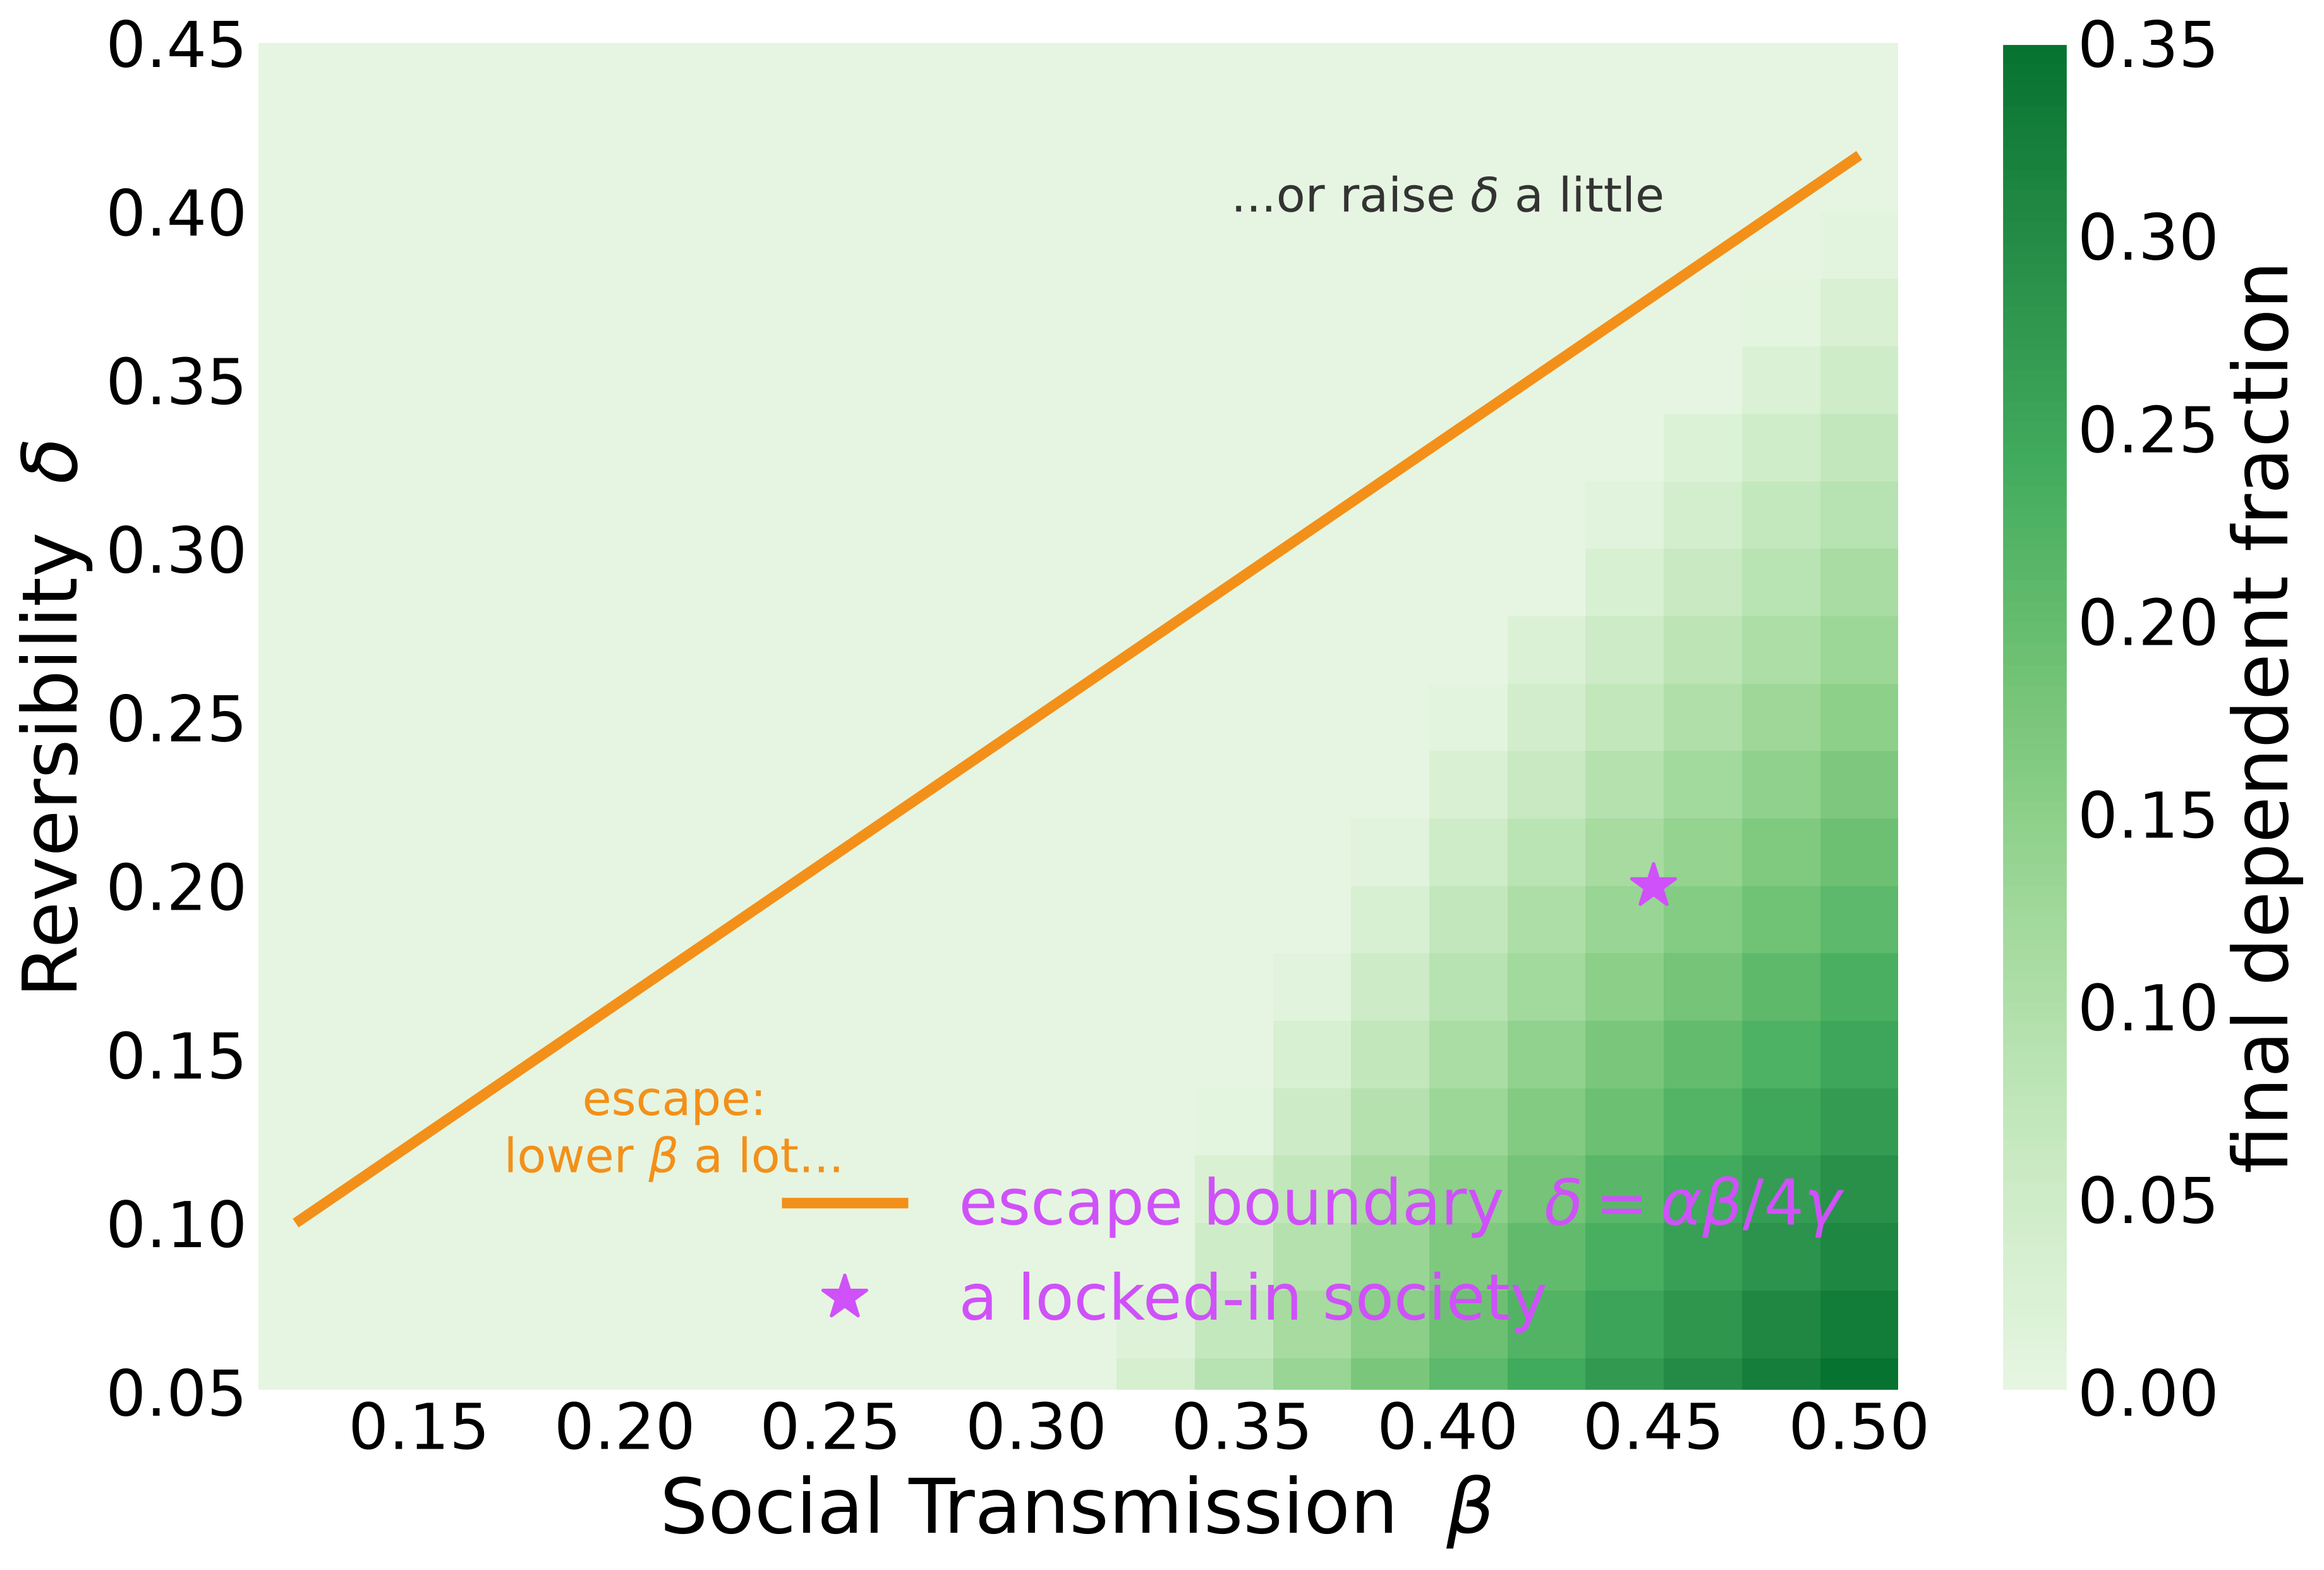

In [16]:
fig, ax = plt.subplots()
cmap = ListedColormap(plt.get_cmap("Greens")(np.linspace(0.12, 0.85, 128)))
im = ax.pcolormesh(betas_g, deltas_g, Z, cmap=cmap, shading="nearest")
bb3 = np.linspace(0.12, 0.50, 100)
ax.plot(bb3, ALPHA * bb3 / (4 * GAMMA), color=colors[3], 
        label=r"escape boundary  $\delta = \alpha\beta/4\gamma$")
ax.plot([0.45], [0.2], marker="*", ms=18, color=colors[1], ls="none",
        label="a locked-in society")
ax.annotate("escape:\nlower $\\beta$ a lot...", (0.212, 0.115), color=colors[3],
            fontsize=18, ha="center")
ax.annotate("...or raise $\\delta$ a little", (0.40, 0.40), color="#333333",
            fontsize=18, ha="center")
ax.set_xlabel(r"Social Transmission  $\beta$")
ax.set_ylabel(r"Reversibility  $\delta$")
ax.set_ylim(0.05, 0.45)
cb = plt.colorbar(im, ax=ax)
cb.set_label("final dependent fraction")
ax.legend(loc="lower right", labelcolor=colors[1])
plt.tight_layout()

The star sits at $(\beta, \delta) = (0.45, 0.2)$ — which, in the model actually
mapped here, is not a locked-in society at all: 13% dependent, with the whole
grid topping out at 35% because without dependent recruitment there is no
runaway branch to reach. Escaping from the star in *this* model means pushing
$\beta$ below $\gamma/(1 - \delta/\alpha) = 0.375$, a 17% cut, or lifting
$\delta$ above $\alpha(1 - \gamma/\beta) = 0.33$, a 67% increase. Friction is
the cheaper lever here, precisely because there is no attractor to dissolve.

Switch recruitment on and the asymmetry in the section title appears. The same
star is now 64% dependent. Transmission control has to drag $\beta$ below
$4\gamma\delta/\alpha = 0.24$, nearly halving the recruiting rate, and it buys
remarkably little on the way down: the population is still 30% dependent at the
instant the state collapses. Reversibility has to clear
$\alpha\beta/4\gamma = 0.375$, a larger relative move, but it erodes the
attractor continuously — down to 12% before it vanishes — and it is the
parameter a tool builder can actually set. **Design conclusion for the essay:
"cognitive immunization" is not about stopping people from talking about LLMs;
it's about engineering the off-ramp** — exportable workflows, skill retention,
the ability to function when the tool is gone. Friction fights the epidemic;
reversibility dissolves the attractor.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px>
</center>